In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

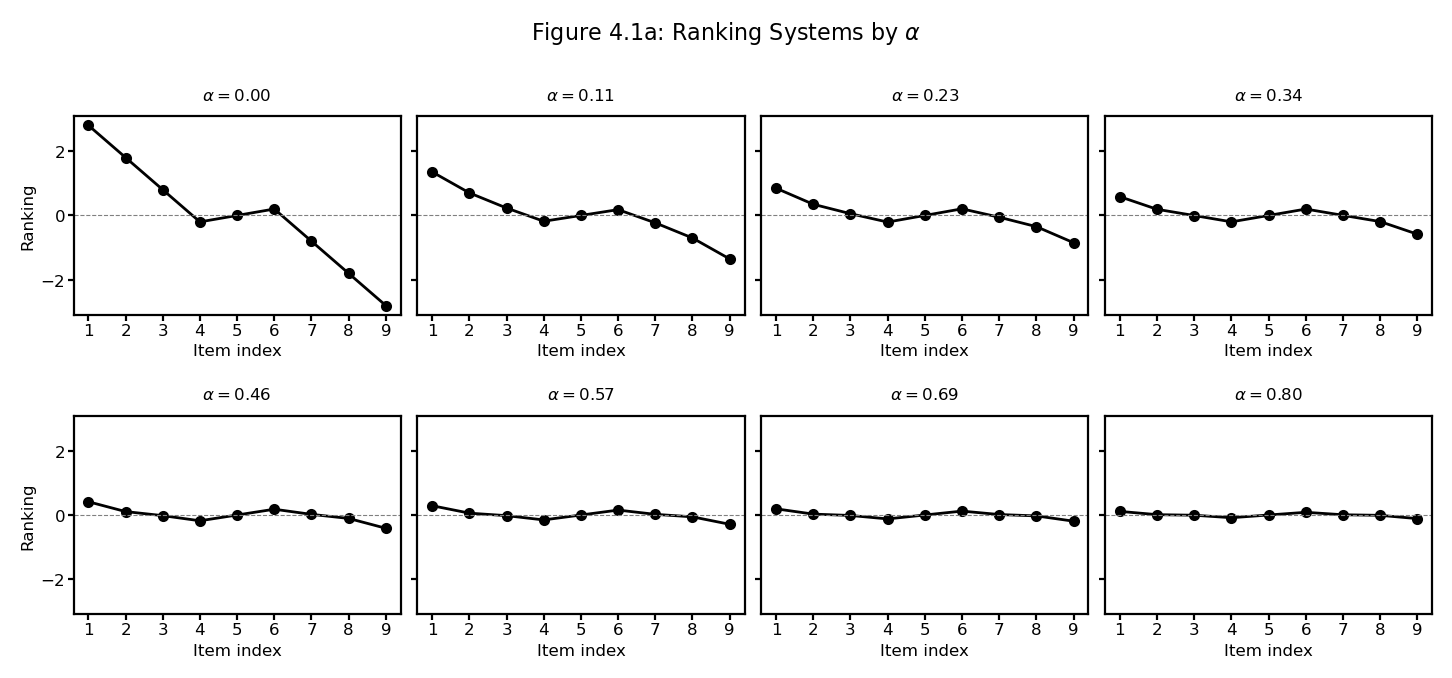

In [2]:
import contextlib, io
from matplotlib import cm

n     = 9
p     = 6
q     = 4

k_s   = 1.0
k_d   = 0.0
c_reg = 1e10

eps    = 1e-10
alphas = np.linspace(0, 0.8, 8)
alphas[0] = eps

x = np.arange(1, n + 1)

colors = cm.viridis(np.linspace(0, 1, len(alphas)))

with plt.rc_context({'figure.dpi': 200}):
    fig, ax = plt.subplots(1, 1, figsize=(4.0, 2.8))

    for a, color in zip(alphas, colors):
        k_o_a = ((1 - a) / 2) * (k_s - k_d)
        with contextlib.redirect_stdout(io.StringIO()):
            sim_a = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                                p=p, q=q, c_reg=c_reg)
        r = sim_a.calc_rank()
        ax.plot(x, r, marker='o', markersize=3, lw=1.2, color=color,
                label=rf'$\alpha = {a:.2f}$')

    ax.axhline(0, color='gray', lw=0.4, ls='--')
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in x], fontsize=7)
    ax.set_xlabel('Item index', fontsize=8, labelpad=3)
    ax.set_ylabel('Ranking', fontsize=8, labelpad=3)
    ax.set_title('Figure 4.1a: Ranking Systems by $\\alpha$', fontsize=9)
    ax.tick_params(axis='both', length=2, pad=2, labelsize=7)
    ax.legend(fontsize=6, loc='upper right', framealpha=0.9)

    plt.tight_layout(pad=0.5)
    plt.show()

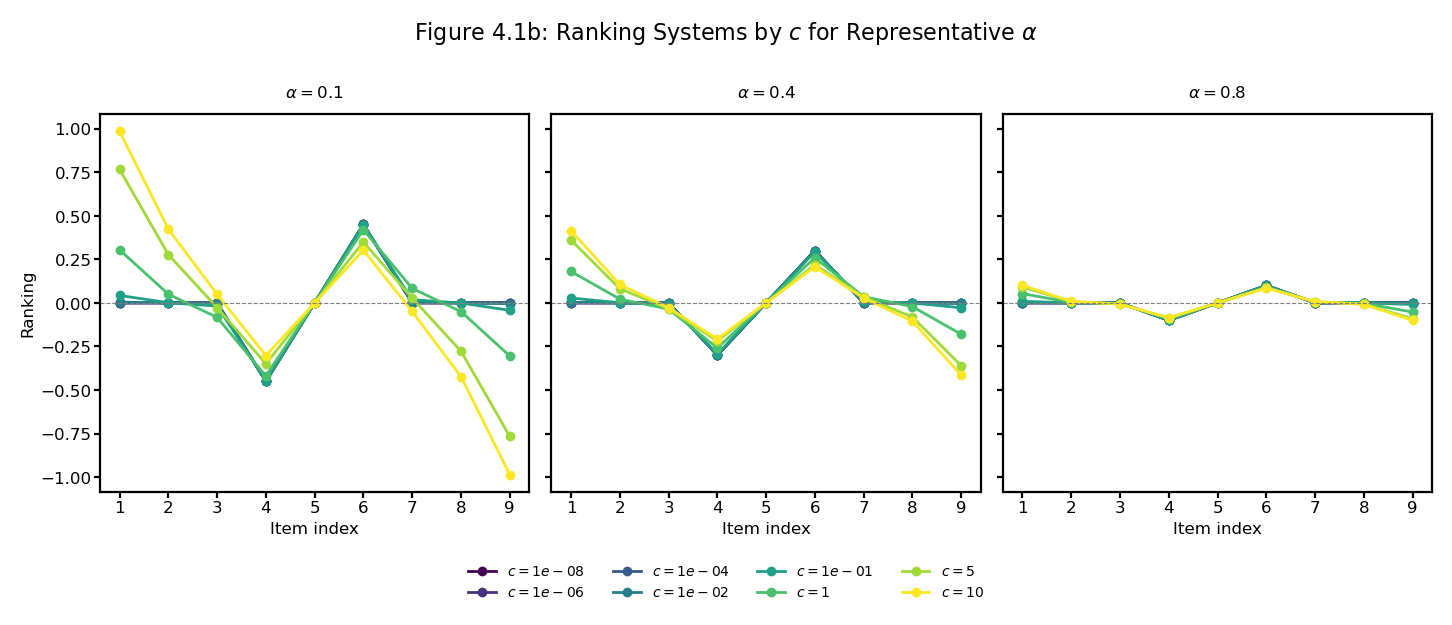

In [3]:
import contextlib, io

n     = 9
p     = 6
q     = 4
k_s   = 1.0
k_d   = 0.0

eps = 1e-10

c_values = [1e-8, 1e-6, 1e-4, 1e-2, 1e-1, 1, 5, 10]
alphas_rep = [0.1, 0.4, 0.8]

x = np.arange(1, n + 1)

cmap = plt.cm.viridis
colors = [cmap(i / (len(c_values) - 1)) for i in range(len(c_values))]

with plt.rc_context({'figure.dpi': 200}):
    fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.6), sharey=True)

    for ax, alpha in zip(axes, alphas_rep):
        k_o_a = ((1 - alpha) / 2) * (k_s - k_d)

        for c_reg, color in zip(c_values, colors):
            with contextlib.redirect_stdout(io.StringIO()):
                sim = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                                  p=p, q=q, c_reg=c_reg)
            r = sim.calc_rank()
            label = f'$c = {c_reg:.0e}$' if c_reg < 1 else f'$c = {c_reg:g}$'
            ax.plot(x, r, marker='o', markersize=2.5, lw=1.0, color=color, label=label)

        ax.axhline(0, color='gray', lw=0.4, ls='--')
        ax.set_xticks(x)
        ax.set_xticklabels([str(k) for k in x], fontsize=6)
        ax.set_xlabel('Item index', fontsize=6, labelpad=2)
        ax.set_title(rf'$\alpha = {alpha}$', fontsize=6)
        ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    axes[0].set_ylabel('Ranking', fontsize=6, labelpad=2)

    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=4, fontsize=5,
               frameon=False, bbox_to_anchor=(0.5, -0.12))

    fig.suptitle('Figure 4.1b: Ranking Systems by $c$ for Representative $\\alpha$',
                 fontsize=8, y=1.02)
    plt.tight_layout(pad=0.5, w_pad=0.6)
    plt.show()